# Dense vs. near-neighbour interactions in a recursively segmented 2D domain

This notebook illustrates how an all-to-all interaction matrix becomes block-sparse when only interactions between neighbouring spatial segments are retained.

The square domain is

\[
[-L/2,L/2]\times[-L/2,L/2].
\]

A recursive quadtree-like segmentation is used:

- depth \(d=0\): \(1\) tile
- depth \(d=1\): \(2\times2=4\) tiles
- depth \(d=2\): \(4\times4=16\) tiles
- depth \(d=3\): \(8\times8=64\) tiles

Thus,

\[
n_{\rm tiles}=4^d.
\]

Instead of choosing \(N\) independently, choose `points_per_tile`. Then

\[
N = 4^d\,\text{points_per_tile},
\]

which guarantees that every leaf tile contains exactly the same number of points.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER PARAMETERS
# ============================================================

L = 1.0

# depth = 1 -> 2 x 2 tiles  = 4 total
# depth = 2 -> 4 x 4 tiles  = 16 total
# depth = 3 -> 8 x 8 tiles  = 64 total
depth = 3

# Exact number of source points in EVERY leaf tile.
points_per_tile = 4

# Softening used only for the illustrative 1/r-like interaction.
softening = 0.02 * L

# ============================================================
# DERIVED QUANTITIES
# ============================================================

tiles_per_axis = 2**depth
n_tiles = tiles_per_axis**2
N = n_tiles * points_per_tile

print(f"depth            = {depth}")
print(f"tiles per axis   = {tiles_per_axis}")
print(f"number of tiles  = {n_tiles}")
print(f"points per tile  = {points_per_tile}")
print(f"total points N   = {N}")


depth            = 3
tiles per axis   = 8
number of tiles  = 64
points per tile  = 4
total points N   = 256


## Generate equal populations tile-by-tile

The points are generated independently inside each leaf tile. This is preferable to making a global point set and then assigning points to tiles, because equal occupancy is guaranteed by construction.

`points_per_tile` can be any positive integer. A small deterministic near-square local grid is used inside each tile.


In [14]:
def generate_equal_points_per_tile(L, depth, points_per_tile):
    # Generate exactly `points_per_tile` source points in every leaf tile.
    if depth < 0 or int(depth) != depth:
        raise ValueError("depth must be a non-negative integer")
    if points_per_tile < 1 or int(points_per_tile) != points_per_tile:
        raise ValueError("points_per_tile must be a positive integer")

    depth = int(depth)
    points_per_tile = int(points_per_tile)

    tiles_per_axis = 2**depth
    tile_size = L / tiles_per_axis

    # Near-square local grid inside each tile.
    local_nx = int(np.ceil(np.sqrt(points_per_tile)))
    local_ny = int(np.ceil(points_per_tile / local_nx))

    local_x = (np.arange(local_nx) + 0.5) / local_nx
    local_y = (np.arange(local_ny) + 0.5) / local_ny

    local_positions = np.array(
        [(x, y) for y in local_y for x in local_x],
        dtype=float,
    )[:points_per_tile]

    positions = []
    tile_xy = []
    tile_ids = []

    # Tile-major ordering:
    # all points belonging to one tile are contiguous in matrix index space.
    for iy in range(tiles_per_axis):
        for ix in range(tiles_per_axis):
            tid = iy * tiles_per_axis + ix

            x0 = -L / 2 + ix * tile_size
            y0 = -L / 2 + iy * tile_size

            for u, v in local_positions:
                positions.append([
                    x0 + u * tile_size,
                    y0 + v * tile_size,
                ])
                tile_xy.append([ix, iy])
                tile_ids.append(tid)

    return (
        np.asarray(positions),
        np.asarray(tile_xy, dtype=int),
        np.asarray(tile_ids, dtype=int),
    )


positions, tile_xy, tile_id = generate_equal_points_per_tile(
    L=L,
    depth=depth,
    points_per_tile=points_per_tile,
)

counts = np.bincount(tile_id, minlength=n_tiles)

assert len(positions) == N
assert np.all(counts == points_per_tile)

print("Unique point counts per tile:", np.unique(counts))
print("Equal occupancy:", np.all(counts == points_per_tile))


Unique point counts per tile: [4]
Equal occupancy: True


## Spatial layout

The source ordering is tile-major. That is intentional: when the matrix is plotted, sources from the same spatial tile form contiguous blocks.


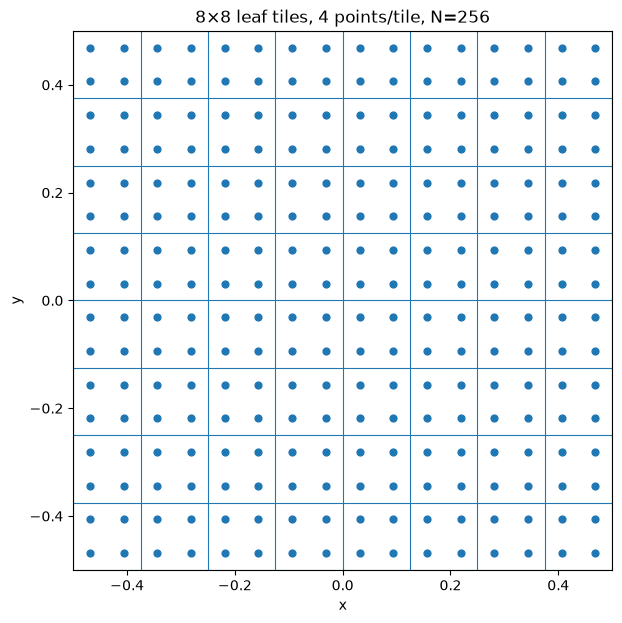

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(positions[:, 0], positions[:, 1], s=24)

tile_edges = np.linspace(-L / 2, L / 2, tiles_per_axis + 1)

for edge in tile_edges:
    ax.axvline(edge, linewidth=0.8)
    ax.axhline(edge, linewidth=0.8)

ax.set_aspect("equal")
ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    f"{tiles_per_axis}×{tiles_per_axis} leaf tiles, "
    f"{points_per_tile} points/tile, N={N}"
)
plt.show()


## Dense all-to-all interaction matrix

For illustration, use

\[
A_{ij}=
\frac{1}{\sqrt{|\mathbf r_i-\mathbf r_j|^2+\epsilon^2}},
\qquad i\neq j,
\]

and \(A_{ii}=0\).

The kernel is only a placeholder. It can later be replaced by a dipolar kernel, demagnetization-tensor component, Green's function, etc.


In [16]:
def make_dense_interaction_matrix(positions, softening):
    dr = positions[:, None, :] - positions[None, :, :]
    r2 = np.sum(dr**2, axis=-1)

    A = 1.0 / np.sqrt(r2 + softening**2)
    np.fill_diagonal(A, 0.0)

    return A


A_dense = make_dense_interaction_matrix(positions, softening)


## Near-neighbour mask

Two sources interact in the near field when their leaf tiles are the same or immediate neighbours:

\[
|\Delta t_x|\le 1,
\qquad
|\Delta t_y|\le 1.
\]

Thus an interior leaf tile interacts with the surrounding \(3\times3\) stencil of tiles.


In [17]:
def make_near_neighbour_mask(tile_xy):
    dx = np.abs(tile_xy[:, None, 0] - tile_xy[None, :, 0])
    dy = np.abs(tile_xy[:, None, 1] - tile_xy[None, :, 1])

    mask = (dx <= 1) & (dy <= 1)

    # Remove self-interaction.
    np.fill_diagonal(mask, False)

    return mask


near_mask = make_near_neighbour_mask(tile_xy)
A_near = np.where(near_mask, A_dense, 0.0)

dense_nnz = np.count_nonzero(A_dense)
near_nnz = np.count_nonzero(A_near)

print(f"Dense nonzeros : {dense_nnz}")
print(f"Near nonzeros  : {near_nnz}")
print(f"Fraction kept  : {near_nnz / dense_nnz:.3f}")


Dense nonzeros : 65280
Near nonzeros  : 7488
Fraction kept  : 0.115


## Heatmap: dense all-to-all matrix


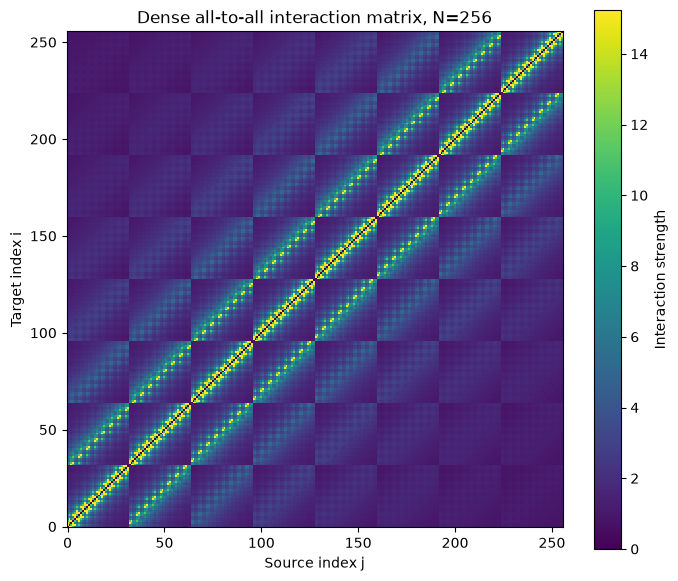

In [18]:
vmax = np.max(A_dense)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    A_dense,
    origin="lower",
    interpolation="nearest",
    aspect="equal",
    vmin=0,
    vmax=vmax,
)
ax.set_title(f"Dense all-to-all interaction matrix, N={N}")
ax.set_xlabel("Source index j")
ax.set_ylabel("Target index i")
fig.colorbar(im, ax=ax, label="Interaction strength")
plt.show()


## Heatmap: near-neighbour-only matrix

The same color scale is used as for the dense matrix.


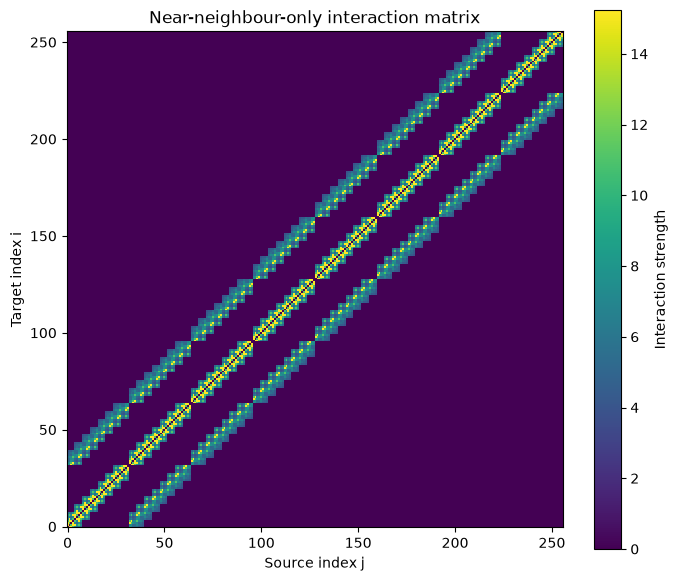

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    A_near,
    origin="lower",
    interpolation="nearest",
    aspect="equal",
    vmin=0,
    vmax=vmax,
)
ax.set_title("Near-neighbour-only interaction matrix")
ax.set_xlabel("Source index j")
ax.set_ylabel("Target index i")
fig.colorbar(im, ax=ax, label="Interaction strength")
plt.show()


## Heatmap: binary sparsity pattern

This strips away the interaction magnitudes and shows only the matrix structure:

- 1 = retained near interaction
- 0 = removed interaction


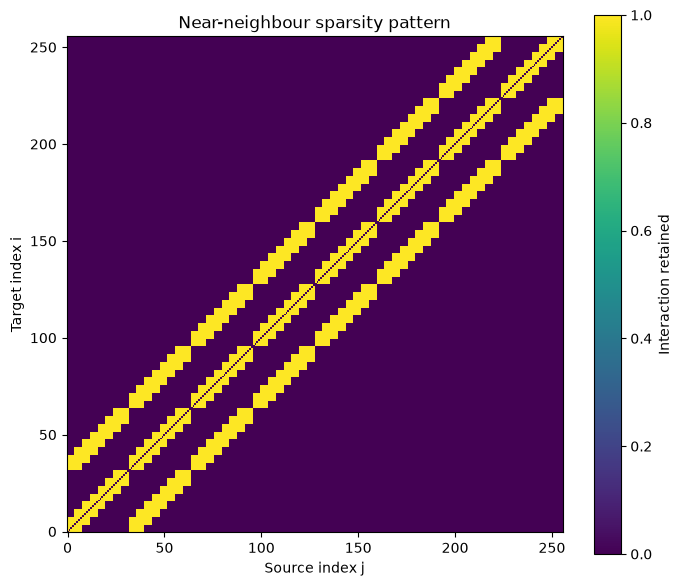

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    near_mask.astype(int),
    origin="lower",
    interpolation="nearest",
    aspect="equal",
    vmin=0,
    vmax=1,
)
ax.set_title("Near-neighbour sparsity pattern")
ax.set_xlabel("Source index j")
ax.set_ylabel("Target index i")
fig.colorbar(im, ax=ax, label="Interaction retained")
plt.show()


## Sparsity pattern with tile-block boundaries

Because there are exactly `points_per_tile` contiguous points per tile, tile boundaries occur every `points_per_tile` matrix rows and columns.


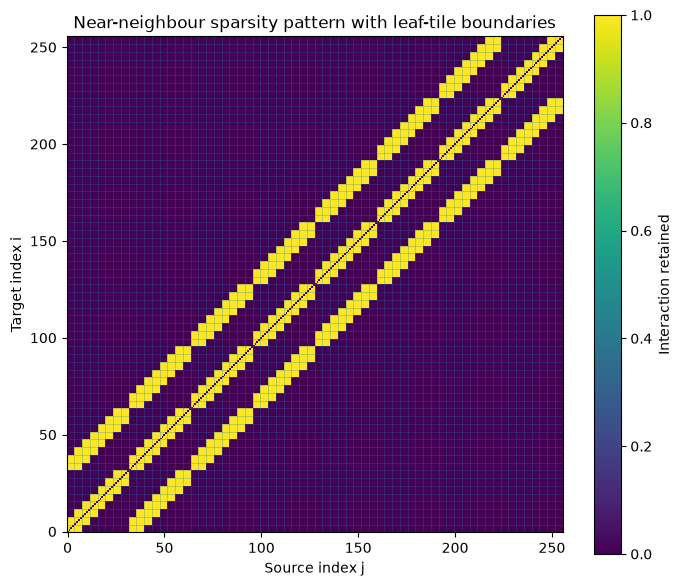

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    near_mask.astype(int),
    origin="lower",
    interpolation="nearest",
    aspect="equal",
    vmin=0,
    vmax=1,
)

for k in range(1, n_tiles):
    boundary = k * points_per_tile - 0.5
    ax.axvline(boundary, linewidth=0.4, alpha=0.5)
    ax.axhline(boundary, linewidth=0.4, alpha=0.5)

ax.set_title("Near-neighbour sparsity pattern with leaf-tile boundaries")
ax.set_xlabel("Source index j")
ax.set_ylabel("Target index i")
fig.colorbar(im, ax=ax, label="Interaction retained")
plt.show()


## Parameter scaling

Change only these parameters near the top:

```python
depth = 2
points_per_tile = 4
```

Examples:

| depth | tiles per axis | total leaf tiles | \(N\) for 4 points/tile |
|---:|---:|---:|---:|
| 1 | 2 | 4 | 16 |
| 2 | 4 | 16 | 64 |
| 3 | 8 | 64 | 256 |
| 4 | 16 | 256 | 1024 |

So the equal-population condition at depth \(d\) is

\[
N \bmod 4^d = 0.
\]

It is therefore not enough in general for \(N\) merely to be a multiple of 4. For depth 2 it must be divisible by 16; for depth 3, by 64; and so on.

Using `points_per_tile` as the primary input enforces this automatically.
